# Homework 5

## Topological Insulators

In [4]:
import numpy as np
import matplotlib.pyplot as plt

### Su-Schrieffer-Heeger (SSH) model

The Su-Schroeffer-Heeger model describes electrons hoping on a 1-D lattice (chain), with staggered hopping amplitudes, as shown in the figure. The chain consists of N unit cells, where each cell hosts two sites, on a Sublattice A, and one on another sublattice B.

![Screenshot 2025-03-23 170903.png](<attachment:Screenshot 2025-03-23 170903.png>)

- The figure shows the geometry of the SSH model, where a single cell is circed by a dotted line. Hopping amplitudes are staggered: intracell hopping v (thin lines) is different from intercell hopping w (thick lines).

Interactions between electrons are negleted, and so the dynamics of each electron can be described using a single-particle hamiltonian:

$$
H = v \sum_{m=1}^{N} \left( |m,B\rangle \langle m,A| + \text{h.c.} \right) 
+ w \sum_{m=1}^{N-1} \left( |m+1,A\rangle \langle m,B| + \text{h.c.} \right).
$$

Here $ |m,B\rangle $ and $ |m,A\rangle $, with $m \in \{1,2,\dots,N\}$, denote the state of the chain where the elctron is on unit cell $m$, in the site on sublattice A, respectively, B and h.c stands for Hermitian Conjugate.

- Note: Hermitian Conjugate means that you reverse the ordering of labels and a take a complex conjugate. For, example, the Hermitian Conjugate of $|m,B\rangle \langle m,A|$ is $|m,A\rangle \langle m,B|$.
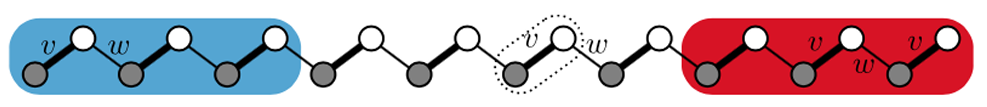

### 1. Find the energy spectrum for the small SSH chain defined above as a function of v/w. It should be similar to this:

![Screenshot 2025-03-23 174022.png](<attachment:Screenshot 2025-03-23 174022.png>)
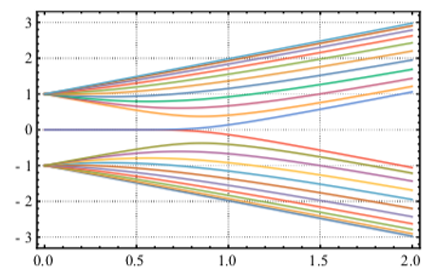

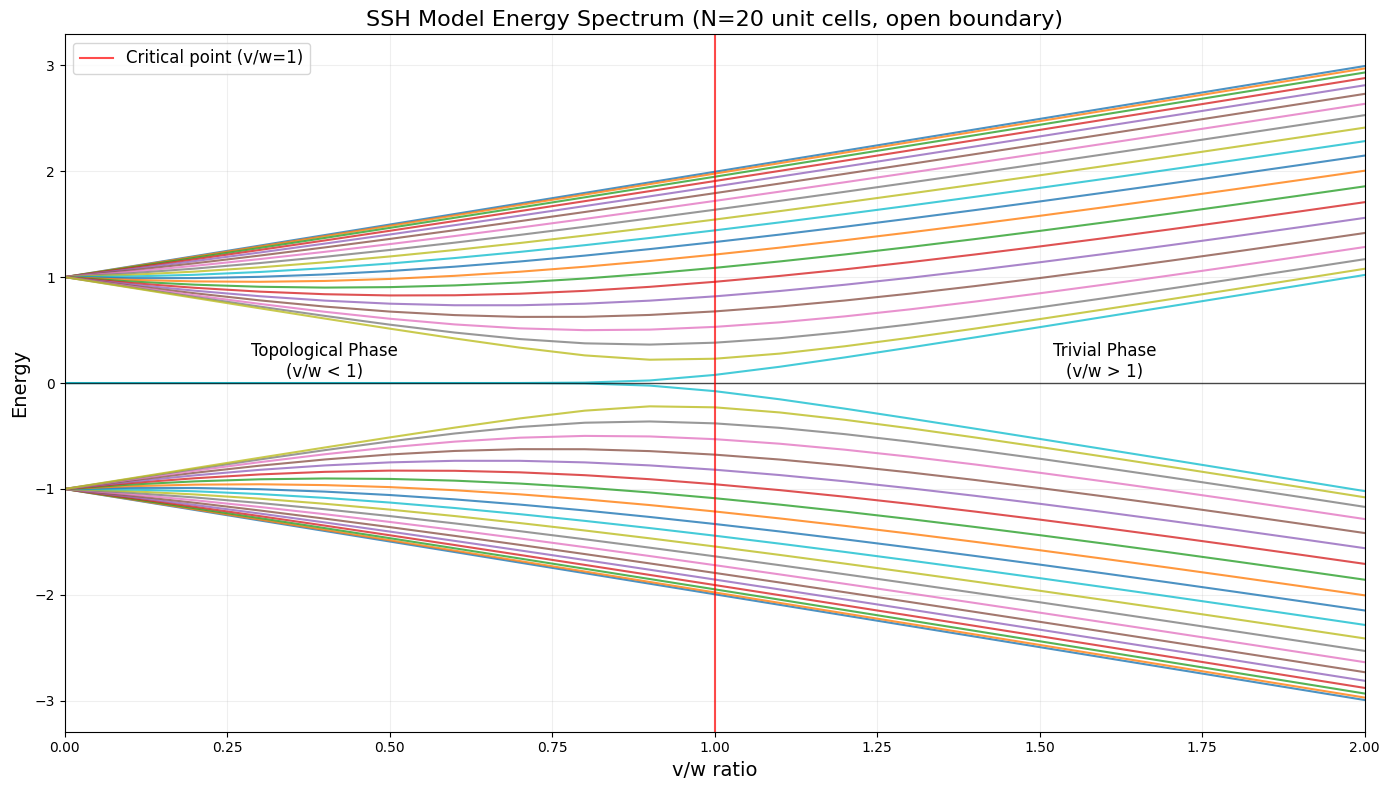

In [14]:
def construct_ssh_hamiltonian(N, v, w):
    """Builds SSH Hamiltonian for an open chain with N unit cells or 2N sites"""
    H = np.zeros((2*N, 2*N))
    for i in range(2*N-1):
        if i % 2 == 0:  # Even index for intracell hopping (A to B)
            H[i,i+1] = v
            H[i+1,i] = v
        else:  # Odd index for intercell hopping (B to A of next cell)
            if i < 2*N-2:
                H[i,i+1] = w
                H[i+1,i] = w
    return H

def calculate_spectrum(N, v_over_w_values):
    """Calculates energy spectrum for v/w ratios"""
    w = 1.0 
    all_spectra = []
    
    for v_over_w in v_over_w_values:
        v = v_over_w * w
        H = construct_ssh_hamiltonian(N, v, w)
        eigenvalues = np.linalg.eigvalsh(H)
        all_spectra.append(eigenvalues)
    
    return all_spectra

N = 20  # Number of unit cells
v_over_w_values = np.linspace(0, 2, 21) 

spectra = calculate_spectrum(N, v_over_w_values)

plt.figure(figsize=(14, 8))

for i in range(N): 
    energies_plus = [spectrum[2*N-1-i] for spectrum in spectra]
    line_plus, = plt.plot(v_over_w_values, energies_plus, linewidth = 1.5, alpha = 0.8)
    
    energies_minus = [spectrum[i] for spectrum in spectra]
    plt.plot(v_over_w_values, energies_minus, '-', color=line_plus.get_color(), linewidth = 1.5, alpha = 0.8)

plt.axhline(0, color='black', linestyle='-', alpha = 0.7, linewidth = 1)
plt.axvline(1, color='red', linestyle='-', alpha = 0.7, linewidth = 1.5, label ='Critical point (v/w=1)')
plt.text(0.4, 0.2, 'Topological Phase\n(v/w < 1)', ha = 'center', va ='center', fontsize = 12)
plt.text(1.6, 0.2, 'Trivial Phase\n(v/w > 1)', ha = 'center', va = 'center', fontsize = 12)

plt.xlabel('v/w ratio', fontsize = 14)
plt.xlim(0, 2)
plt.ylabel('Energy', fontsize = 14)
plt.title(f'SSH Model Energy Spectrum (N={N} unit cells, open boundary)', fontsize = 16)
plt.grid(True, alpha = 0.2)
plt.legend(fontsize = 12)
plt.tight_layout()
plt.show()

### Bulk Hamiltonian

As every solid-state sysytem, the long chain of the SSH model has a bulk and a boundary. The bulk is the long central part of the chain and the boundary are the edges (incluiding the shaded parts in the figure shown above).

The physics in the bulk shouldn't depend on how the edges are defined, so for simplicity's sake, we'll set periodic boundary conditions. <ins>This is equivalent to closing the chain into a ring</ins>, with the bulk hamiltonian defined as:

$$
H_{\text{bulk}} = N \sum_{m=1}^{N} \left( v |m,B\rangle \langle m,A| 
+ w |(m \mod N) + 1,A\rangle \langle m,B| \right) + \text{h.c.}
$$

We are looking for eigenstates of this hamiltonian,

$$
H_{\text{bulk}} | \Psi(k) \rangle = E(k) | \Psi(k) \rangle
$$

#### Bulk momentum-space Hamiltonian

Due to the translation invariance of the bulk, Bloch's theorem applies, and we look for eigenstates in a plane wave form. We introdce the plane wave basis states only for the external degreen of freedom,

$$
|k \rangle = \sum_{m=1}^{N} e^{i m k} |m \rangle, \quad \text{for } k \in \{\delta k, 2 \delta k, \dots, N \delta k\}, \quad \text{with  } \delta k = \frac{2 \pi}{N}
$$

where the wavenumber k varies between $ 0 \leq k < 2\pi $. The bloch eigenstates read

$$
|\Psi_n(k) \rangle = |k \rangle \otimes |u_n(k) \rangle; \quad |u_n(k) \rangle = a_n(k) |A \rangle + b_n(k) |B \rangle
$$

The vectors $|u_n(k) \rangle \in H_{\text{internal}}$ are eigenstates of the bulk momentum-space Hamiltonian $\hat{H}(k)$ defined as

$$
\hat{H}(k) = \langle k | \hat{H}_{\text{bulk}} | k \rangle = \sum_{\alpha, \beta \in \{A, B\}} \langle k, \alpha | {H}_{\text{bulk}} | k, \beta \rangle \cdot | \alpha \rangle \langle \beta |
$$

$$
\hat{H}(k) |u_n(k) \rangle = E_n(k) |u_n(k) \rangle
$$

#### Dispersion of the bulk

The dispersion of the bulk is

$$
E_{\pm}(k) = \pm \left| v + e^{-ik w} \right| = \sqrt{v^2 + w^2 + 2vw \cos(k)}
$$

As long as the hopping amplitudes are sttaggered, $v \neq w$, there is an energy gap of $ 2\Delta $ separating the lower, filled band, from the upper empty band.

If $v = w$, <ins>the SSH model describes a conductor</ins>. In that case there are plane wave eigenstates of the bulk available with arbitrarily small energy, which can transport electrons from one end of the chain to the other.

#### The winding vector

The bulk momentum-space Hamiltonian $\hat{H}(k)$ of any two-band model (or 2 internal states per unit cell), reads 

$$
H(k) = d_x(k) \hat{\sigma}_x + d_y(k) \hat{\sigma}_y + d_z(k) \hat{\sigma}_z = d_0(k) \hat{\sigma}_0 + \mathbf{d}(k) \cdot \hat{\boldsymbol{\sigma}}
$$

For the SSH model, $ d_0(k) = 0 $ and the real numbers $ d_{x,y,z} \in \mathbb{R} $, the components of the k-dependent 3-dimensional vector $\mathbf{d}(k)$, read

$$
d_x(k) = v + w \cos k, \quad d_y(k) = w \sin k, \quad d_z(k) = 0
$$

The internal structure of the eigenstates with momentum k is given by the direction in which the vector $\mathbf{d}(k)$ points (the energy is given by the magnnitude of $\mathbf{d}(k)$). As the wavenumber runs through the Brillouin zone, $ k = 0 \rightarrow 2\pi $, the path that the endpoint of the vector $\mathbf{d}(k)$ traces out is a closed circle or radius $w$ on the $ d_x, d_y$ plane, centered $(v, 0)$.

![Screenshot 2025-03-23 231402.png](<attachment:Screenshot 2025-03-23 231402.png>)

- Figure shows dispersion relations of the SSH model, for five settings of the hopping amplitudes: (a): $v = 1, w = 0$; (b): $v = 1, w = 0.6$; (c): $ v = w = 1;$ (d): $ v = 0.6, w = 1$; (e): $v = 0, w = 1$. In each case, the path of the endpoints of the vector $\mathbf{d}(k)$ representing the bulk momentum-space Hamiltonian are also shown on the $ d_x, d_y$ plane, as the wavenumber is sweeped across the Brillouin zone, $ k = 0 \rightarrow 2\pi $.

For the SSH model, the winding number is either 0 or 1, depending on the parameters. When the intracell hopping dominates intercell hopping, $v > w$, the winding number is $v = 0$. In the topological case, when $v < w$, we have $v = 1$, and a topological phase transition.

To alter the winding number $v$ of the SSH model, we need to either (a) pull the path of $\mathbf{d}(k)$ through the origen in the $ d_x, d_y$ plane, or (b) lift it out of the plane and put it back on the plane in a different position.

- Method (a) requires closing the bulk gap.
- Method (b) requires breaking chiral symmetry.


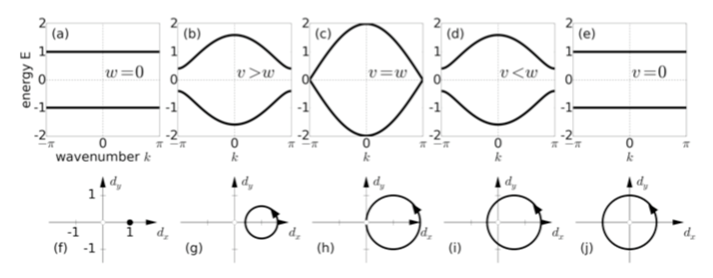

### 2. Obtain all plots shown in the figure above

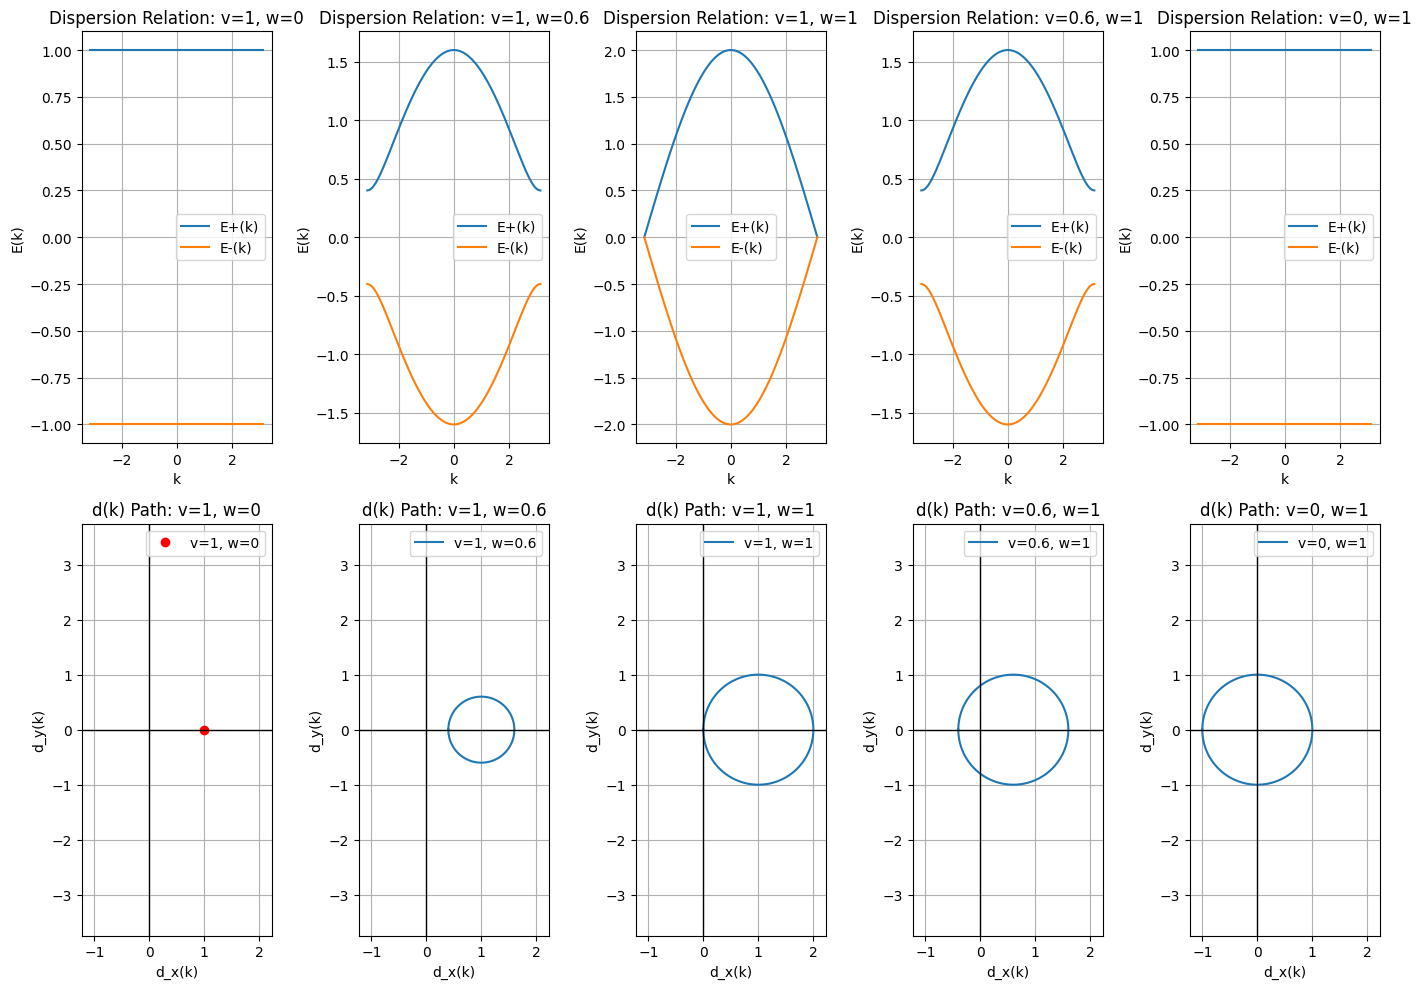

In [12]:
def bulk_hamiltonian(k, v, w):
    H = np.array([[0, v + w * np.exp(-1j * k)],
                 [v + w * np.exp(1j * k), 0]])
    return H

def dispersion_relation(k, v, w):
    return np.sqrt(v**2 + w**2 + 2 * v * w * np.cos(k))

def d_vector(k, v, w):
    dx = v + w * np.cos(k)
    dy = w * np.sin(k)
    return dx, dy

# Parameters
k_values = np.linspace(-np.pi, np.pi, 100)
v_w_settings = [(1, 0), (1, 0.6), (1, 1), (0.6, 1), (0, 1)]

plt.figure(figsize = (14, 10))

for i, (v, w) in enumerate(v_w_settings):
    # Calculate dispersion relation
    E_plus = dispersion_relation(k_values, v, w)
    E_minus = -E_plus

    # Calculate d(k) paths
    dx, dy = d_vector(k_values, v, w)

    plt.subplot(2, len(v_w_settings), i + 1)
    plt.plot(k_values, E_plus, label='E+(k)')
    plt.plot(k_values, E_minus, label='E-(k)')
    plt.title(f'Dispersion Relation: v={v}, w={w}')
    plt.xlabel('k')
    plt.ylabel('E(k)')
    plt.legend()
    plt.grid(True)

    plt.subplot(2, len(v_w_settings), len(v_w_settings) + i + 1)
    if w == 0:
        plt.plot(v, 0, 'ro', label=f'v={v}, w={w}') # w = 0 -> gives a simple dot at (v, 0)
    else:
        plt.plot(dx, dy, label=f'v={v}, w={w}')

    plt.axhline(0, color = 'black', linewidth = 1, linestyle = '-')
    plt.axvline(0, color = 'black', linewidth = 1, linestyle = '-')
    plt.title(f'd(k) Path: v={v}, w={w}')
    plt.xlabel('d_x(k)')
    plt.ylabel('d_y(k)')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.xlim(-1.5, 2.5)

plt.tight_layout()
plt.show()    

### Edge states

Like any material, the SSH Hamiltonian isn't just made up of a bulk part, but also boundaries too (usually referred to as edges).

The distinction between bulk and edge describes the behaviour of energy eigenstates in the thermodynamic limit. In this case, the bulk is considered translation invariant, so then edge and bulk states can be distinguished by their localized behaviour at the thermodynamic limit.

The SSH model becomes simpler in two fully dimerized cases: if the intercell hopping amplitude vanishes and the intercell hopping is set to 1, $v = 1, w = 0$ or $v = 0, w = 1$. In both cases the SSH chain falls apart, turning into a sequence of disconnected dimers, as shown below.

![Screenshot 2025-03-24 152650.png](<attachment:Screenshot 2025-03-24 152650.png>)

- Figure shows fully dimerized limits of the SSH model, where the chain is broken into small disconnect dimers. For intracell hopping,  $v = 1, w = 0$, every energy eigenstate is either an even or odd superposition of two sites at the same unit cell. For intercell hopping, $v = 0, w = 1$, dimers are between neighbouring unit cells, and there is one isolated site per edge, that must contain one zero-energy eigenstate each, as there onsite potentials.

Now what we happen when we move away from the fully dimerized limit?

As the intracell hopping amplitude $v$ increases, the energies of the edge states remain very close to zero energy.

The wavefunctions of almost-zero energy edge states have to be exponentially localized at the left/right edge, because the zero of the energy is in the bulk band gap. A plot of wavefunctions (which have only real components, as the Hamiltonian is real) reveals that the almost zero-energy eigenstates are odd and even superpositions of states localized exponentially on the left and right side.
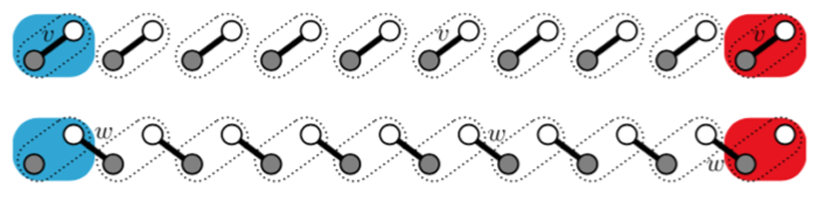

### 3.Plot the edge states amplitudes for several values of v/w

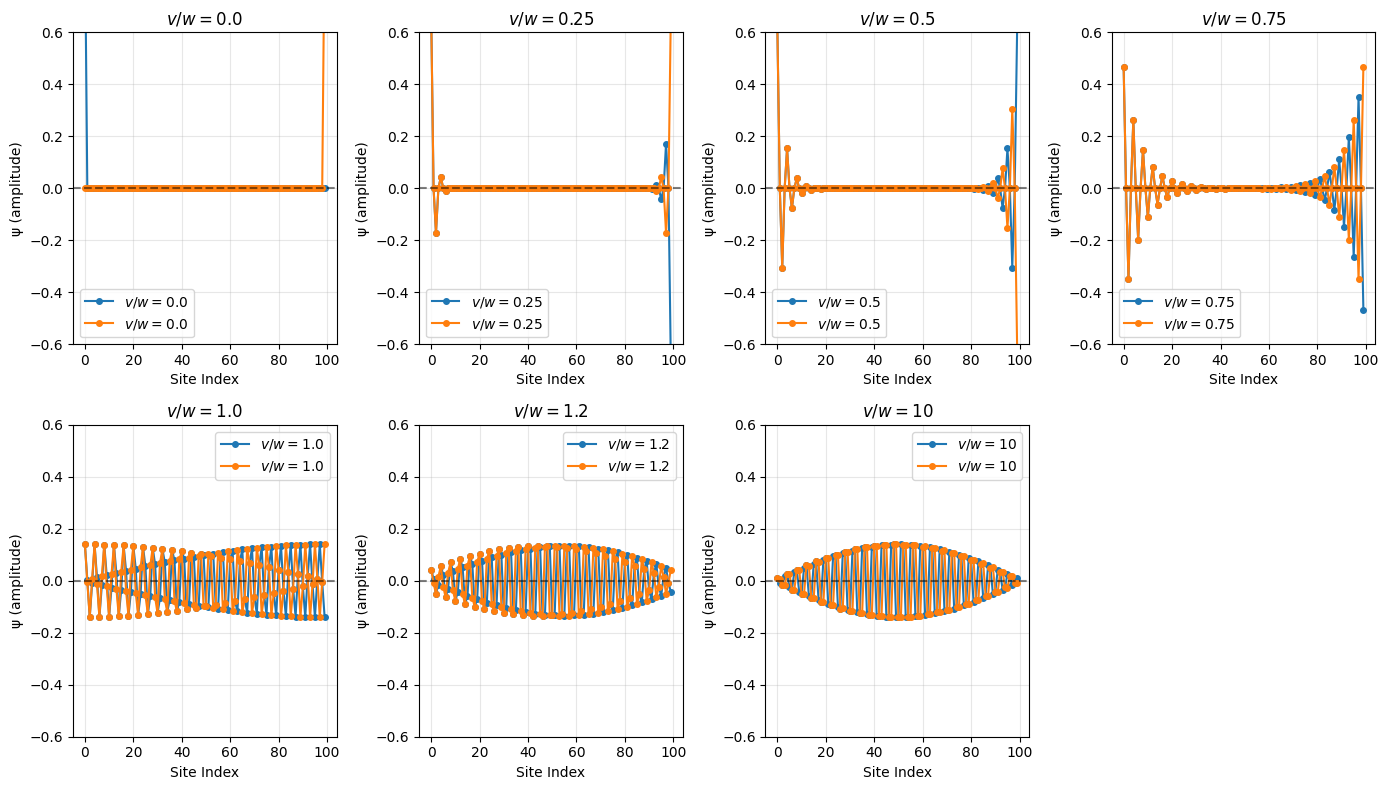

In [32]:
import numpy as np
import matplotlib.pyplot as plt

def construct_ssh_hamiltonian(N, v, w):
    """Builds SSH Hamiltonian for an open chain."""
    H = np.zeros((2*N, 2*N))
    for m in range(N):
        H[2*m, 2*m+1] = v   # Intracell hopping v
        H[2*m+1, 2*m] = v
        if m < N-1:         # Intercell hopping w
            H[2*m+1, 2*(m+1)] = w
            H[2*(m+1), 2*m+1] = w
    return H

def plot_wavefunctions(v_over_w_values, N=50):
    """Plots wavefunction amplitudes (ψ) for different v/w ratios."""
    plt.figure(figsize=(14, 8))
    
    for i, v_over_w in enumerate(v_over_w_values):
        v = v_over_w
        w = 1.0  
        H = construct_ssh_hamiltonian(N, v, w)
        eigvals, eigvecs = np.linalg.eigh(H)
        
        # Find two states closest to zero energy
        zero_energy_indices = np.argsort(np.abs(eigvals))[:2]
        edge_states = eigvecs[:, zero_energy_indices]
        
        plt.subplot(2, len(v_over_w_values)//2 + 1, i + 1)
        for state in edge_states.T:
            # Plot both positive and negative ψ values
            plt.plot(state, 'o-', markersize=4, label=f'$v/w = {v_over_w}$')
        
        plt.title(f'$v/w = {v_over_w}$')
        plt.xlabel('Site Index')
        plt.ylabel('ψ (amplitude)')
        plt.axhline(0, color='black', linestyle='--', alpha=0.5)  # Zero line
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.ylim(-0.6, 0.6)  # Symmetric y-axis to show both positive/negative values
    
    plt.tight_layout()
    plt.show()

v_over_w_values = [0.0, 0.25, 0.5, 0.75, 1.0, 1.20, 10] 
plot_wavefunctions(v_over_w_values)

So for v/w < 1, we have more easily distinguishable, localized, states. As we approach the critical point, v/w = 1, the edge state amplitudes are no longer localized and blend in with the bulk states. Then for v/w > 1 we enter the trivial topological phase in which there no longer any edges, as shown by the null edge state amplitudes.